In [1]:
from google.colab import files
import urllib.request
import subprocess
import sys

code_url = "https://raw.githubusercontent.com/msim0039-bit/mma3001-sensor-project/main/src/audit.py"
urllib.request.urlretrieve(code_url, "audit.py")

uploaded = files.upload()
zip_name = next(iter(uploaded))

subprocess.run([sys.executable, "audit.py", zip_name], check=True)

Saving 5EnvSensor_MayToDec2024_180kRows.zip to 5EnvSensor_MayToDec2024_180kRows.zip


CompletedProcess(args=['/usr/bin/python3', 'audit.py', '5EnvSensor_MayToDec2024_180kRows.zip'], returncode=0)

In [2]:
import csv
import io
import json
import zipfile
from collections import defaultdict

sensor_id = "6012002000869"
variable_times = defaultdict(set)
variable_metadata = {}

with zipfile.ZipFile(zip_name) as archive:
    csv_name = next(
        name for name in archive.namelist()
        if name.lower().endswith(".csv")
    )

    with archive.open(csv_name) as raw_file:
        text_file = io.TextIOWrapper(raw_file, encoding="utf-8-sig")

        for row in csv.DictReader(text_file):
            if row["sensorid"] != sensor_id:
                continue

            for measurement in json.loads(row["jsondata"]):
                variable = measurement.get("variable", {})
                name = variable.get("name", "Unknown")
                variable_metadata[name] = variable

                for item in measurement.get("values", []):
                    timestamp = item.get("time")
                    value = item.get("value")

                    if timestamp is not None and value is not None:
                        variable_times[name].add(timestamp)

print("Sensor:", sensor_id)

for name in sorted(variable_times):
    print(f"\n{name}: {len(variable_times[name]):,} distinct timestamps")
    print("Variable details:", variable_metadata[name])

co2_times = variable_times.get("Carbon dioxide", set())

print("\nExact timestamp matches with CO₂:")
for name in sorted(variable_times):
    if name != "Carbon dioxide":
        matches = len(co2_times & variable_times[name])
        print(f"{name}: {matches:,}")

Sensor: 6012002000869

Battery: 13,800 distinct timestamps
Variable details: {'id': 66, 'name': 'Battery', 'unit': 'V', 'source': 0, 'structure': 32834}

Carbon dioxide: 13,800 distinct timestamps
Variable details: {'id': 67, 'name': 'Carbon dioxide', 'unit': 'ppm', 'source': 0, 'structure': 32835}

Formaldehyde: 13,800 distinct timestamps
Variable details: {'id': 70, 'name': 'Formaldehyde', 'unit': 'µg/m3', 'source': 0, 'structure': 32847}

Humidity: 13,800 distinct timestamps
Variable details: {'id': 72, 'name': 'Humidity', 'unit': 'HR%', 'source': 0, 'structure': 32840}

Light Volatile Organic Compounds: 13,800 distinct timestamps
Variable details: {'id': 99, 'name': 'Light Volatile Organic Compounds', 'unit': 'ppb', 'source': 0, 'structure': 32867}

Particulate matter 1: 13,800 distinct timestamps
Variable details: {'id': 47, 'name': 'Particulate matter 1', 'unit': 'µg/m3', 'source': 1, 'structure': 33071}

Particulate matter 10: 13,800 distinct timestamps
Variable details: {'id': 

In [3]:
import math
import pandas as pd

selected_variables = [
    "Carbon dioxide",
    "Temperature",
    "Humidity",
    "Pressure",
]

values_by_variable = {
    name: defaultdict(set) for name in selected_variables
}
invalid_counts = dict.fromkeys(selected_variables, 0)

with zipfile.ZipFile(zip_name) as archive:
    csv_name = next(
        name for name in archive.namelist()
        if name.lower().endswith(".csv")
    )

    with archive.open(csv_name) as raw_file:
        text_file = io.TextIOWrapper(raw_file, encoding="utf-8-sig")

        for row in csv.DictReader(text_file):
            if row["sensorid"] != sensor_id:
                continue

            for measurement in json.loads(row["jsondata"]):
                name = measurement.get("variable", {}).get("name")
                if name not in values_by_variable:
                    continue

                for item in measurement.get("values", []):
                    try:
                        timestamp = float(item["time"])
                        value = float(item["value"])
                        if not (
                            math.isfinite(timestamp)
                            and math.isfinite(value)
                        ):
                            raise ValueError
                    except (KeyError, TypeError, ValueError):
                        invalid_counts[name] += 1
                        continue

                    values_by_variable[name][timestamp].add(value)

# Identical duplicates collapse to one value.
# Conflicting values become missing rather than being chosen arbitrarily.
clean_values = {}
for name in selected_variables:
    records = values_by_variable[name]
    conflicts = sum(len(values) > 1 for values in records.values())

    clean_values[name] = {
        timestamp: next(iter(values)) if len(values) == 1 else float("nan")
        for timestamp, values in records.items()
    }

    print(
        f"{name}: {invalid_counts[name]:,} invalid records; "
        f"{conflicts:,} conflicting timestamps"
    )

sensor_table = pd.DataFrame(clean_values).sort_index()
sensor_table.index.name = "timestamp_seconds"

print(f"\nTotal timestamps: {len(sensor_table):,}")
print(
    "Rows with all four valid measurements:",
    f"{sensor_table.notna().all(axis=1).sum():,}",
)
print("\nMissing or conflicting values per column:")
print(sensor_table.isna().sum())

print("\nMeasurement ranges:")
display(sensor_table.agg(["min", "max"]))

print("\nFirst five rows:")
display(sensor_table.head())

Carbon dioxide: 0 invalid records; 0 conflicting timestamps
Temperature: 0 invalid records; 0 conflicting timestamps
Humidity: 0 invalid records; 0 conflicting timestamps
Pressure: 0 invalid records; 0 conflicting timestamps

Total timestamps: 13,800
Rows with all four valid measurements: 13,800

Missing or conflicting values per column:
Carbon dioxide    0
Temperature       0
Humidity          0
Pressure          0
dtype: int64

Measurement ranges:


,Carbon dioxide,Temperature,Humidity,Pressure
min,403.0,19.0,26.0,1002.0
max,646.0,28.5,75.0,1028.0



First five rows:


,Carbon dioxide,Temperature,Humidity,Pressure
timestamp_seconds,,,,
1.709187e+09,465.0,24.3,56.0,1010.0
1.709187e+09,445.0,24.0,56.0,1010.0
1.709188e+09,471.0,23.8,56.0,1010.0
1.709189e+09,457.0,23.8,56.0,1010.0
1.709190e+09,455.0,23.8,57.0,1010.0


In [4]:
import numpy as np

# Use separate names to preserve the earlier exploration.
comparison_times = sensor_table.index.to_numpy(dtype=float)
comparison_co2 = sensor_table["Carbon dioxide"].to_numpy(dtype=float)

feature_names = ["Temperature", "Humidity", "Pressure"]
comparison_features = sensor_table[feature_names].to_numpy(dtype=float)

n_readings = len(sensor_table)
training_end = int(0.50 * n_readings)
comparison_start = training_end
comparison_end = int(0.75 * n_readings)

X_train = comparison_features[:training_end]
y_train = comparison_co2[:training_end]

assert np.all(np.diff(comparison_times) > 0)
assert np.isfinite(X_train).all()
assert np.isfinite(y_train).all()
assert comparison_times[training_end - 1] < comparison_times[comparison_start]

print(f"Regression training rows: {training_end:,}")
print(
    f"Method comparison rows: "
    f"{comparison_end - comparison_start:,}"
)
print(
    f"Remaining rows outside this comparison: "
    f"{n_readings - comparison_end:,}"
)
print("Regression inputs:", ", ".join(feature_names))
print("Regression output: CO₂ in ppm")
print("Training and comparison sections do not overlap.")

Regression training rows: 6,900
Method comparison rows: 3,450
Remaining rows outside this comparison: 3,450
Regression inputs: Temperature, Humidity, Pressure
Regression output: CO₂ in ppm
Training and comparison sections do not overlap.


In [5]:
# Scale the inputs using statistics from the training section only.
feature_mean = X_train.mean(axis=0)
feature_scale = X_train.std(axis=0)

if np.any(feature_scale == 0):
    raise ValueError("A training input has no variation.")

X_train_scaled = (X_train - feature_mean) / feature_scale

# The column of ones allows the model to fit an intercept.
training_matrix = np.column_stack([
    np.ones(len(X_train_scaled)),
    X_train_scaled,
])

# Fit coefficients by least squares.
regression_coefficients, _, regression_rank, _ = np.linalg.lstsq(
    training_matrix,
    y_train,
    rcond=None,
)

if regression_rank != training_matrix.shape[1]:
    raise ValueError("The regression inputs are linearly dependent.")


def predict_co2_regression(features):
    """Predict CO₂ in ppm from temperature, humidity, and pressure."""
    features = np.asarray(features, dtype=float)

    if features.ndim != 2 or features.shape[1] != 3:
        raise ValueError("Inputs must have three columns.")
    if not np.isfinite(features).all():
        raise ValueError("Inputs must contain finite numbers.")

    scaled = (features - feature_mean) / feature_scale
    prediction_matrix = np.column_stack([
        np.ones(len(scaled)),
        scaled,
    ])
    return prediction_matrix @ regression_coefficients


print("Regression fitted using training data only.")
print(f"Intercept: {regression_coefficients[0]:.3f} ppm")

for name, coefficient in zip(
    feature_names, regression_coefficients[1:]
):
    print(f"{name}: {coefficient:.3f} ppm per training standard deviation")

Regression fitted using training data only.
Intercept: 469.614 ppm
Temperature: 6.515 ppm per training standard deviation
Humidity: 2.929 ppm per training standard deviation
Pressure: 5.184 ppm per training standard deviation


In [6]:
from scipy.interpolate import CubicSpline

methods = ["previous", "linear", "cubic_spline", "regression"]
comparison_results = []

context_points = 4
maximum_interval_seconds = 30 * 60

for gap_size in [6, 18, 36]:
    errors = {method: [] for method in methods}
    durations_minutes = []
    gap_count = 0

    for start in range(
        comparison_start + context_points,
        comparison_end - gap_size - context_points + 1,
        gap_size + 8,
    ):
        stop = start + gap_size

        # Skip windows containing an existing long time gap.
        window_times = comparison_times[
            start - context_points:stop + context_points
        ]
        if np.any(np.diff(window_times) > maximum_interval_seconds):
            continue

        # Four observed CO₂ readings on each side.
        # None of the hidden readings enter the spline.
        context_indices = np.concatenate([
            np.arange(start - context_points, start),
            np.arange(stop, stop + context_points),
        ])

        hidden_times = comparison_times[start:stop]
        actual = comparison_co2[start:stop]

        left_time = comparison_times[start - 1]
        right_time = comparison_times[stop]
        left_value = comparison_co2[start - 1]
        right_value = comparison_co2[stop]

        spline = CubicSpline(
            comparison_times[context_indices] - left_time,
            comparison_co2[context_indices],
            bc_type="natural",
            extrapolate=False,
        )

        predictions = {
            "previous": np.full(gap_size, left_value),
            "linear": (
                left_value
                + (right_value - left_value)
                * (hidden_times - left_time)
                / (right_time - left_time)
            ),
            "cubic_spline": spline(hidden_times - left_time),
            "regression": predict_co2_regression(
                comparison_features[start:stop]
            ),
        }

        # Use hidden CO₂ values only to measure prediction errors.
        for method, predicted in predictions.items():
            if not np.isfinite(predicted).all():
                raise ValueError(f"Non-finite predictions: {method}")
            errors[method].extend(predicted - actual)

        durations_minutes.append((right_time - left_time) / 60)
        gap_count += 1

    if gap_count == 0:
        raise ValueError(f"No eligible gaps for size {gap_size}.")

    for method in methods:
        error = np.asarray(errors[method])
        comparison_results.append({
            "Hidden readings": gap_size,
            "Gaps evaluated": gap_count,
            "Method": method,
            "MAE (ppm)": np.mean(np.abs(error)),
            "RMSE (ppm)": np.sqrt(np.mean(error**2)),
            "Median boundary interval (min)": np.median(
                durations_minutes
            ),
        })

comparison_results_table = pd.DataFrame(comparison_results)
display(comparison_results_table.round(2))

,Hidden readings,Gaps evaluated,Method,MAE (ppm),RMSE (ppm),Median boundary interval (min)
0,6,246,previous,13.05,18.16,79.98
1,6,246,linear,9.81,12.82,79.98
2,6,246,cubic_spline,18.49,23.61,79.98
3,6,246,regression,35.19,45.93,79.98
4,18,132,previous,17.04,23.49,209.97
5,18,132,linear,11.62,15.22,209.97
6,18,132,cubic_spline,39.31,52.10,209.97
7,18,132,regression,35.47,46.16,209.97
8,36,78,previous,30.75,41.68,400.00
9,36,78,linear,16.60,21.88,400.00


In [7]:
# 1. A natural cubic spline should recover a straight line,
# even when the observation times are unevenly spaced.
known_times = np.array([0, 2, 5, 9, 12, 16], dtype=float)
known_co2 = 400 + 2 * known_times
query_times = np.array([3, 6, 10], dtype=float)

test_spline = CubicSpline(
    known_times,
    known_co2,
    bc_type="natural",
    extrapolate=False,
)

np.testing.assert_allclose(
    test_spline(query_times),
    [406, 412, 420],
    rtol=0,
    atol=1e-9,
)
print("PASS: cubic spline recovers a known straight line.")

# 2. The spline must pass through its observed data points.
np.testing.assert_allclose(
    test_spline(known_times),
    known_co2,
    rtol=0,
    atol=1e-9,
)
print("PASS: cubic spline preserves observed values.")

# 3. At the training input means, every scaled input is zero,
# so the regression prediction must equal its intercept.
mean_prediction = predict_co2_regression(
    feature_mean.reshape(1, 3)
)
np.testing.assert_allclose(
    mean_prediction,
    [regression_coefficients[0]],
    rtol=0,
    atol=1e-9,
)
print("PASS: regression predicts its intercept at mean inputs.")

# 4. The regression must reject invalid inputs.
invalid_inputs = [
    np.array([[20, 50]]),           # Wrong number of columns
    np.array([20, 50, 1010]),       # Wrong array shape
    np.array([[20, np.nan, 1010]]), # Missing value
    np.array([[20, 50, np.inf]]),   # Infinite value
]

for features in invalid_inputs:
    try:
        predict_co2_regression(features)
    except ValueError:
        continue
    raise AssertionError("Regression accepted an invalid input.")

print("PASS: regression rejects all four invalid input cases.")

PASS: cubic spline recovers a known straight line.
PASS: cubic spline preserves observed values.
PASS: regression predicts its intercept at mean inputs.
PASS: regression rejects all four invalid input cases.


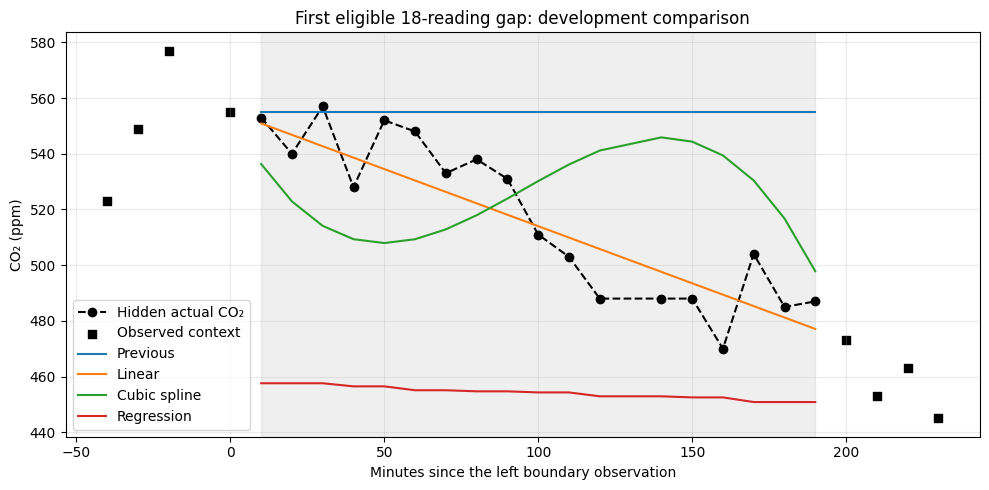

In [8]:
import matplotlib.pyplot as plt

# Select the first eligible 18-reading gap, before examining its errors.
example_gap_size = 18
example_start = None

for start in range(
    comparison_start + context_points,
    comparison_end - example_gap_size - context_points + 1,
    example_gap_size + 8,
):
    stop = start + example_gap_size
    window = comparison_times[
        start - context_points:stop + context_points
    ]
    if np.all(np.diff(window) <= maximum_interval_seconds):
        example_start = start
        break

if example_start is None:
    raise ValueError("No eligible example gap.")

start = example_start
stop = start + example_gap_size
context_indices = np.concatenate([
    np.arange(start - context_points, start),
    np.arange(stop, stop + context_points),
])

origin = comparison_times[start - 1]
hidden_seconds = comparison_times[start:stop] - origin
hidden_minutes = hidden_seconds / 60

left_value = comparison_co2[start - 1]
right_value = comparison_co2[stop]
boundary_seconds = comparison_times[stop] - origin

example_spline = CubicSpline(
    comparison_times[context_indices] - origin,
    comparison_co2[context_indices],
    bc_type="natural",
    extrapolate=False,
)

example_predictions = {
    "Previous": np.full(example_gap_size, left_value),
    "Linear": (
        left_value
        + (right_value - left_value)
        * hidden_seconds / boundary_seconds
    ),
    "Cubic spline": example_spline(hidden_seconds),
    "Regression": predict_co2_regression(
        comparison_features[start:stop]
    ),
}

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    hidden_minutes,
    comparison_co2[start:stop],
    "ko--",
    label="Hidden actual CO₂",
)
ax.scatter(
    (comparison_times[context_indices] - origin) / 60,
    comparison_co2[context_indices],
    color="black",
    marker="s",
    label="Observed context",
)

for name, predicted in example_predictions.items():
    ax.plot(hidden_minutes, predicted, label=name)

ax.axvspan(
    hidden_minutes[0], hidden_minutes[-1],
    color="grey", alpha=0.12,
)
ax.set_xlabel("Minutes since the left boundary observation")
ax.set_ylabel("CO₂ (ppm)")
ax.set_title("First eligible 18-reading gap: development comparison")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

In [9]:
fig.savefig(
    "co2_example_gap.png",
    dpi=200,
    bbox_inches="tight",
)

comparison_results_table.to_csv(
    "co2_method_comparison.csv",
    index=False,
)

print("Saved co2_example_gap.png")
print("Saved co2_method_comparison.csv")

Saved co2_example_gap.png
Saved co2_method_comparison.csv


In [10]:
from google.colab import files

files.download("co2_example_gap.png")
files.download("co2_method_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
result = subprocess.run(
    [sys.executable, "audit.py", zip_name],
    capture_output=True,
    text=True,
    check=True,
)
print(result.stdout)

Sensor ID: 6012002000869
CSV rows for sensor: 29341
Distinct timestamp/value pairs: 13800
Distinct measurement timestamps: 13800
Timestamps with conflicting CO2 values: 0
Unit: ppm



In [ ]:
import csv
import io
import json
import zipfile
from datetime import datetime, timezone
import numpy as np

readings = {}

with zipfile.ZipFile(zip_name) as archive:
    csv_name = next(
        name for name in archive.namelist()
        if name.lower().endswith(".csv")
    )

    with archive.open(csv_name) as raw_file:
        rows = csv.DictReader(io.TextIOWrapper(raw_file, encoding="utf-8-sig"))

        for row in rows:
            if row["sensorid"] != "6012002000869":
                continue

            for measurement in json.loads(row["jsondata"]):
                if measurement.get("variable", {}).get("name") == "Carbon dioxide":
                    for item in measurement.get("values", []):
                        readings[int(item["time"])] = float(item["value"])

times = np.array(sorted(readings))
co2 = np.array([readings[time] for time in times])
intervals_minutes = np.diff(times) / 60

print("First measurement (UTC):", datetime.fromtimestamp(int(times[0]), timezone.utc))
print("Last measurement (UTC): ", datetime.fromtimestamp(int(times[-1]), timezone.utc))
print("Number of readings:", len(co2))
print("CO2 range (ppm):", co2.min(), "to", co2.max())
print("Median interval (minutes):", np.median(intervals_minutes))
print("90th percentile interval (minutes):", np.percentile(intervals_minutes, 90))
print("Largest interval (minutes):", intervals_minutes.max())

First measurement (UTC): 2024-02-29 06:04:56+00:00
Last measurement (UTC):  2024-06-13 17:45:44+00:00
Number of readings: 13800
CO2 range (ppm): 403.0 to 646.0
Median interval (minutes): 10.0
90th percentile interval (minutes): 19.953333333333344
Largest interval (minutes): 29.983333333333334


In [ ]:
# Keep the actual readings as ground truth, but hide six from the methods.
start = 1000
hidden = slice(start, start + 6)

true_values = co2[hidden]
hidden_times = times[hidden]

left_time, right_time = times[start - 1], times[start + 6]
left_value, right_value = co2[start - 1], co2[start + 6]

# Baseline: carry the last available reading forward.
previous_value = np.full(6, left_value)

# Linear interpolation: use both readings around the gap.
linear = left_value + (
    (hidden_times - left_time) / (right_time - left_time)
) * (right_value - left_value)

print("Actual CO2 (ppm):          ", true_values)
print("Previous-value estimate:  ", previous_value)
print("Linear estimate (ppm):    ", np.round(linear, 1))
print("Previous-value MAE (ppm): ", np.mean(np.abs(true_values - previous_value)))
print("Linear MAE (ppm):         ", np.mean(np.abs(true_values - linear)))

Actual CO2 (ppm):           [470. 462. 475. 455. 466. 470.]
Previous-value estimate:   [446. 446. 446. 446. 446. 446.]
Linear estimate (ppm):     [446.2 446.4 446.9 447.1 447.3 447.8]
Previous-value MAE (ppm):  20.333333333333332
Linear MAE (ppm):          19.37037037037037


In [ ]:
# Reserve the final 25% of readings for this evaluation.
test_start = int(0.75 * len(co2))

for gap_size in (6, 18, 36):
    previous_errors = []
    linear_errors = []
    gap_count = 0

    # Move past each tested window so hidden readings do not overlap.
    for start in range(test_start + 1, len(co2) - gap_size, gap_size + 8):
        window_times = times[start - 1:start + gap_size + 1]

        # Skip windows containing an existing break longer than 30 minutes.
        if np.any(np.diff(window_times) > 30 * 60):
            continue

        actual = co2[start:start + gap_size]
        target_times = times[start:start + gap_size]

        left_time = times[start - 1]
        right_time = times[start + gap_size]
        left_value = co2[start - 1]
        right_value = co2[start + gap_size]

        previous = np.full(gap_size, left_value)
        interpolated = left_value + (
            (target_times - left_time) / (right_time - left_time)
        ) * (right_value - left_value)

        previous_errors.extend(np.abs(actual - previous))
        linear_errors.extend(np.abs(actual - interpolated))
        gap_count += 1

    print(
        f"{gap_size} hidden readings | {gap_count} gaps | "
        f"previous MAE: {np.mean(previous_errors):.2f} ppm | "
        f"linear MAE: {np.mean(linear_errors):.2f} ppm"
    )

6 hidden readings | 246 gaps | previous MAE: 11.02 ppm | linear MAE: 8.14 ppm
18 hidden readings | 132 gaps | previous MAE: 14.02 ppm | linear MAE: 9.57 ppm
36 hidden readings | 78 gaps | previous MAE: 15.72 ppm | linear MAE: 11.61 ppm


In [ ]:
import urllib.request
from datetime import datetime, timedelta

url = "https://raw.githubusercontent.com/msim0039-bit/mma3001-sensor-project/main/src/reconstruct.py"
urllib.request.urlretrieve(url, "reconstruct.py")

from reconstruct import reconstruct_gap

start = datetime(2024, 3, 1, 12, 0)
end = start + timedelta(minutes=30)
missing = [start + timedelta(minutes=10), start + timedelta(minutes=20)]

print("Previous:", reconstruct_gap(start, 400, missing, end, 430, "previous"))
print("Linear:", reconstruct_gap(start, 400, missing, end, 430, "linear"))

Previous: [400.0, 400.0]
Linear: [410.0, 420.0]


In [ ]:
from datetime import datetime, timedelta
import numpy as np

# Hide six real readings, starting at position 1000.
start_index = 1000
gap_size = 6

def as_datetime(seconds):
    return datetime(1970, 1, 1) + timedelta(seconds=float(seconds))

left_time = as_datetime(times[start_index - 1])
right_time = as_datetime(times[start_index + gap_size])
hidden_times = [
    as_datetime(t) for t in times[start_index:start_index + gap_size]
]

left_value = co2[start_index - 1]
right_value = co2[start_index + gap_size]
actual = co2[start_index:start_index + gap_size]

for method in ("previous", "linear"):
    predicted = reconstruct_gap(
        left_time, left_value, hidden_times, right_time, right_value, method
    )
    mae = np.mean(np.abs(actual - predicted))
    print(f"{method}: MAE = {mae:.2f} ppm")

previous: MAE = 20.33 ppm
linear: MAE = 19.37 ppm


In [ ]:
from time import perf_counter

evaluation_start = int(0.50 * len(co2))
evaluation_end = int(0.75 * len(co2))

for gap_size in (6, 18, 36):
    errors = {"previous": [], "linear": []}
    runtimes = {"previous": 0.0, "linear": 0.0}
    gap_count = 0

    # Leave space between tested gaps so their hidden readings do not overlap.
    for start in range(
        evaluation_start + 1,
        evaluation_end - gap_size,
        gap_size + 8,
    ):
        window_times = times[start - 1:start + gap_size + 1]

        # Exclude windows that already have a break longer than 30 minutes.
        if np.any(np.diff(window_times) > 30 * 60):
            continue

        hidden_times = [as_datetime(t) for t in times[start:start + gap_size]]
        actual = co2[start:start + gap_size]

        for method in ("previous", "linear"):
            begin = perf_counter()
            predicted = reconstruct_gap(
                as_datetime(times[start - 1]),
                co2[start - 1],
                hidden_times,
                as_datetime(times[start + gap_size]),
                co2[start + gap_size],
                method,
            )
            runtimes[method] += perf_counter() - begin
            errors[method].extend(actual - np.array(predicted))

        gap_count += 1

    print(f"\n{gap_size} hidden readings | {gap_count} tested gaps")
    for method in ("previous", "linear"):
        error = np.array(errors[method])
        if len(error):
            mae = np.mean(np.abs(error))
            rmse = np.sqrt(np.mean(error ** 2))
            print(
                f"{method}: MAE {mae:.2f} ppm | "
                f"RMSE {rmse:.2f} ppm | "
                f"method time {runtimes[method]:.4f} s"
            )


6 hidden readings | 246 tested gaps
previous: MAE 13.20 ppm | RMSE 17.45 ppm | method time 0.0016 s
linear: MAE 9.79 ppm | RMSE 12.50 ppm | method time 0.0024 s

18 hidden readings | 132 tested gaps
previous: MAE 18.42 ppm | RMSE 25.36 ppm | method time 0.0011 s
linear: MAE 12.45 ppm | RMSE 16.20 ppm | method time 0.0023 s

36 hidden readings | 78 tested gaps
previous: MAE 27.30 ppm | RMSE 38.00 ppm | method time 0.0009 s
linear: MAE 15.94 ppm | RMSE 21.00 ppm | method time 0.0021 s


In [ ]:
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

base_url = "https://raw.githubusercontent.com/msim0039-bit/mma3001-sensor-project/main/"

with tempfile.TemporaryDirectory() as folder:
    project = Path(folder)
    for filename in ("src/reconstruct.py", "tests/test_reconstruct.py"):
        destination = project / filename
        destination.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(base_url + filename, destination)

    result = subprocess.run(
        [sys.executable, "-m", "unittest", "discover", "-s", "tests", "-v"],
        cwd=project,
        capture_output=True,
        text=True,
    )
    print(result.stdout)
    print(result.stderr)
    print("Exit code:", result.returncode)


test_linear_recovers_known_straight_line (test_reconstruct.TestReconstructGap.test_linear_recovers_known_straight_line) ... ok
test_previous_uses_last_observed_value (test_reconstruct.TestReconstructGap.test_previous_uses_last_observed_value) ... ok
test_rejects_time_outside_gap (test_reconstruct.TestReconstructGap.test_rejects_time_outside_gap) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.001s

OK

Exit code: 0


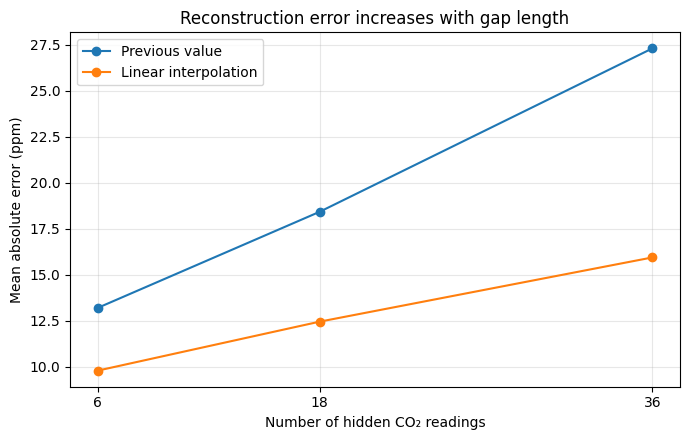

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# MAE values from the separate evaluation section above.
gap_sizes = np.array([6, 18, 36])
previous_mae = [13.20, 18.42, 27.30]
linear_mae = [9.79, 12.45, 15.94]

plt.figure(figsize=(7, 4.5))
plt.plot(gap_sizes, previous_mae, "o-", label="Previous value")
plt.plot(gap_sizes, linear_mae, "o-", label="Linear interpolation")

plt.xlabel("Number of hidden CO₂ readings")
plt.ylabel("Mean absolute error (ppm)")
plt.title("Reconstruction error increases with gap length")
plt.xticks(gap_sizes)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("co2_gap_mae.png", dpi=200)
plt.show()

In [ ]:
from google.colab import files
files.download("co2_gap_mae.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>